In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

In [2]:
# нуль термопары
V_0 = np.float128('-0.03') # mV

# Погрешность V
sigma_V = np.float128('0.01') # mV

# перевод в кельвины
T_0 = np.float128("273.15") # K

Комнатная температура $t_0 = 24.5~ C^\circ$

In [3]:
t_0 = np.float128('24.5')
sigma_t_0 = np.float128('0.5')

Снимем зависимость температуры от ЭДС термопары

In [4]:
# EDS [мкВ]
# T   [C]
thermo_calib = pd.read_csv("thermopair.csv")


Приблизим разными много членами

In [5]:
def polynom(x, *args):
    return np.sum(
        [args[i] * np.power(x, i) for i in range(len(args))]
        , axis=0)

In [6]:
n_s = list(range(2, 5))

approximations = []

for n in n_s:
    x = thermo_calib["EDS"]
    y = thermo_calib["T"]

    popt, pcov = curve_fit(polynom, x, y, p0=tuple((1 for _ in range(n))))

    x_model = np.linspace(0, 5000, 10000)
    y_model = polynom(x_model, *popt)

    approximations.append(
        (n, x_model, y_model, popt, np.sqrt(np.diag(pcov)))
    )


[ 1.64719389e-01  2.55150331e-02 -5.08125035e-07]
[5.45825366e-02 5.37128352e-05 1.10511475e-08]
T = 0.16471938900395056 + 0.025515033084366978*EDS + -5.081250351590683e-07* EDS**2


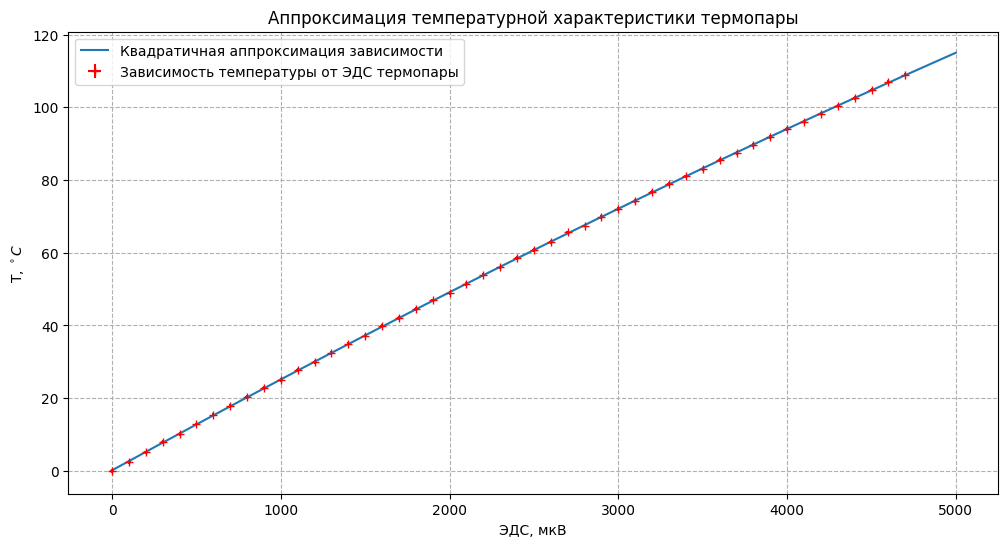

In [7]:
plt.figure(figsize=(12, 6))
plt.grid(True, linestyle="--")

plt.title(r"Аппроксимация температурной характеристики термопары")


plt.errorbar(x=thermo_calib["EDS"], xerr=10, y=thermo_calib["T"], yerr=0.5, fmt="+r", label=r"Зависимость температуры от ЭДС термопары")

for n, x_, y_, p, p_err in approximations:
    if n != 3:
        continue

    print(p)
    print(p_err)

    a_0, a_1, a_2 = p
    sigma_a_0, sigma_a_1, sigma_a_2 = p_err

    print(f"T = {a_0} + {a_1}*EDS + {a_2}* EDS**2")

    plt.plot(x_, y_, label=r"Квадратичная аппроксимация зависимости")

plt.xlabel(r"ЭДС, мкВ")
plt.ylabel(r"T, $^\circ C$")

plt.legend()

plt.savefig("pictures/thermopair_approximation.pdf")
plt.show()


Температура от ЭДС

$$ t(\varepsilon) = a_0 + a_1 \varepsilon + a_2 \varepsilon^2 $$

Погрешность

$$ \sigma_t = \sqrt{ \left( \cfrac{\partial t}{\partial a_0} \right)^2 \sigma_{a_0}^2 + \left( \cfrac{\partial t}{\partial a_1} \right)^2 \sigma_{a_1}^2 + \left( \cfrac{\partial t}{\partial a_2} \right)^2 \sigma_{a_2}^2 + \left(\cfrac{\partial t}{\partial \varepsilon} \right)^2 \sigma_\varepsilon^2 } = \sqrt{ \sigma_{a_0}^2 + \varepsilon^2 \sigma_{a_1}^2 + \varepsilon^4 \sigma_{a_2}^2 + \left(a_1 + 2 \varepsilon a_2 \right)^2 \sigma_\varepsilon^2 } $$

In [8]:
print(f"a = {a_0:.2f} +- {sigma_a_0:.2f}")
print(f"b = {a_1:.4f} +- {sigma_a_1:.4f}")
print(f"c = {a_2:.8f} +- {sigma_a_2:.8f}")

a = 0.16 +- 0.05
b = 0.0255 +- 0.0001
c = -0.00000051 +- 0.00000001


In [9]:
def t_from_eds(eds):
    return a_0 + a_1*eds + a_2* eds**2

def sigma_t_from_eds(eds, sigma_eds):
    return np.sqrt(
        np.square(sigma_a_0) + 
        np.square(eds * sigma_a_1) + 
        np.square(eds**2 * sigma_a_2) + 
        np.square(a_1 + 2 * eds * a_2) * np.square(sigma_eds)
    )

Измеряем $R_2$, которое выставляем в [Ом], к нему измеряем ЭДС на термопаре $V$ в [mV]. Так же на всякий случай частота

In [10]:
data = pd.read_csv("data.csv")

data["V_true"] = data["V"] - V_0

data["t"] = t_from_eds(1000 * data["V_true"]) + t_0
data["sigma_t"] = sigma_t_from_eds(1000 * data["V_true"], 1000 * sigma_V)

data

,R_2,V,f,V_true,t,sigma_t
0,274.3,-0.03,600,0.00,24.664719,0.260923
1,257.0,0.16,600,0.19,29.494232,0.259237
2,227.0,0.37,600,0.40,34.789433,0.257852
3,203.0,0.53,600,0.56,38.793790,0.257150
4,173.0,0.74,600,0.77,44.010028,0.256715
5,150.0,0.91,600,0.94,48.199871,0.256792
6,125.0,1.14,600,1.17,53.821736,0.257552
7,101.0,1.38,600,1.41,59.630713,0.259215
8,85.0,1.59,600,1.62,64.665550,0.261464
9,64.2,1.93,600,1.96,72.722171,0.266831


Электропроводность

$$ \sigma = \cfrac{l}{S} \cfrac{R_1}{R_3} \cfrac{1}{R_2} $$

$$ \sigma_\sigma = \sigma \sqrt{\left( \cfrac{\sigma_l}{l} \right)^2 + \left( \cfrac{\sigma_S}{S} \right)^2 + \left( \cfrac{\sigma_{R_1}}{R_1} \right)^2 + \left( \cfrac{\sigma_{R_3}}{R_3} \right)^2 + \left( \cfrac{\sigma_{R_2}}{R_2} \right)^2} $$

Погрешность логарифма электропроводности

$$ \sigma_{\ln {\sigma}} = \sqrt{\left( \cfrac{\partial \ln{\sigma}}{\partial \sigma} \right)^2 \sigma_\sigma^2} = \left| \cfrac{1}{\sigma} \right| \sigma_\sigma = \cfrac{\sigma_\sigma}{\sigma} $$

Сопротивления

$R_1 = (220 \pm 0.5)~\text{Ом}$

$R_3 = (560 \pm 0.5)~\text{Ом}$

In [11]:
R_1 = np.float128('220')
sigma_R_1 = np.float128('0.5')

R_3 = np.float128('560')
sigma_R_3 = np.float128('0.5')


# Погрешность выставления на магазине сопротивлений
sigma_R_2 = np.float128('0.005')

Размеры образца:

$a = (40 \pm 0.5)~\text{мм}$

$b = (4.1 \pm 0.05)~\text{мм}$

$c = (4.15 \pm 0.005)~\text{мм}$

Тогда длина $l = a$

А площадь

$$ S = bc; \ \ \ \ \sigma_S = S \sqrt{\left( \cfrac{\sigma_b}{b} \right)^2 + \left( \cfrac{\sigma_c}{c} \right)^2} $$

In [12]:
# парметры
a = np.float128('40')
sigma_a = np.float128('0.5')

b = np.float128('4.1')
sigma_b = np.float128('0.05')

c = np.float128('4.15')
sigma_c = np.float128('0.005')

# Длина [м]
l = a / 1e3
sigma_l = sigma_a / 1e3

# площадь [м^2]
S = b * c / 1e6
sigma_S = S * np.sqrt(
    np.square(sigma_b / b) + np.square(sigma_c / c)
)

In [13]:
# Считаем электропроводность в СИ и ее ln
data["sigma"] = l * R_1 / R_3 / S / data["R_2"]

data["sigma_sigma"] = data["sigma"] * np.sqrt(
    np.square(sigma_l / l) + 
    np.square(sigma_R_1 / R_1) + 
    np.square(sigma_R_3 / R_3) + 
    np.square(sigma_S / S) + 
    np.square(sigma_R_2 / data["R_2"])
)

data["ln_sigma"] = np.log(data["sigma"])
data["sigma_ln_sigma"] = data["sigma_sigma"] / data["sigma"]

# Считаем температуру в кельвинах и обратную
data["T"] = data["t"] + T_0
data["sigma_T"] = data["sigma_t"]

data["1/T"] = 1 / data["T"]
data["sigma_1/T"] = data["1/T"] * data["sigma_T"] / data["T"]

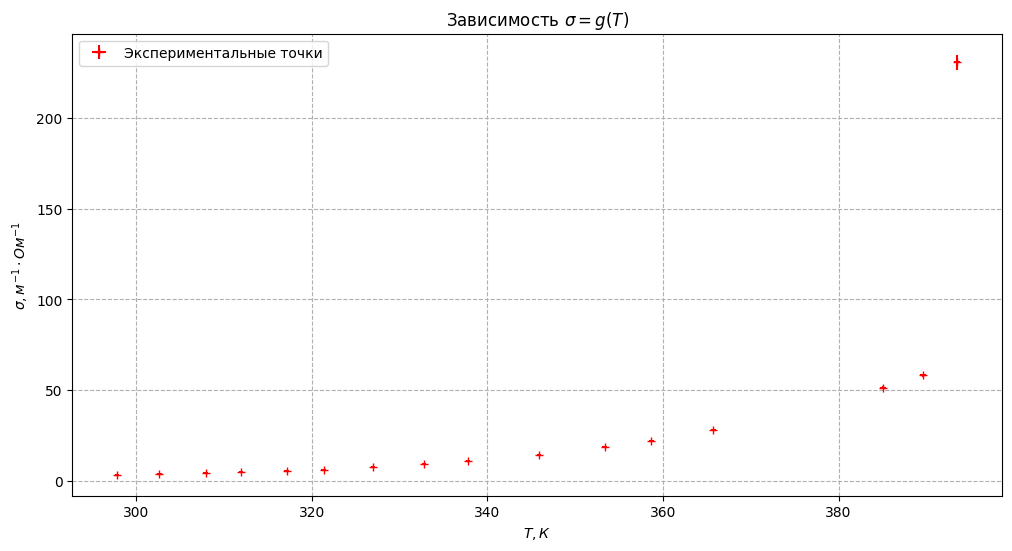

In [14]:
plt.figure(figsize=(12, 6))
plt.grid(True, linestyle="--")
plt.title(r"Зависимость $\sigma = g(T)$")

plt.errorbar(x=data["T"], xerr=data["sigma_T"], y=data["sigma"], yerr=data["sigma_sigma"], fmt="+r", label="Экспериментальные точки")

plt.xlabel(r"$T, К$")
plt.ylabel(r"$\sigma, м^{-1} \cdot Ом^{-1}$")

plt.legend()
plt.savefig("pictures/sigma_T_graph.pdf")
plt.show()


Для зависимости $\ln \sigma = f(1 / T)$


$$ \sigma = A \exp{\left( - \cfrac{\Delta}{2 k_\text{Б} T} \right)} $$

$$ \ln \sigma = \ln A - \cfrac{\Delta}{2 k_\text{Б} T} = B + \cfrac{C}{T} $$

In [15]:
def linear(x, k, b):
    return k*x + b

ln sigma = 15.273074029781975 -4295.9611883539865 / T
B = 15.3 +- 1.0
C = (43.0 +- 3) * 1e2 К


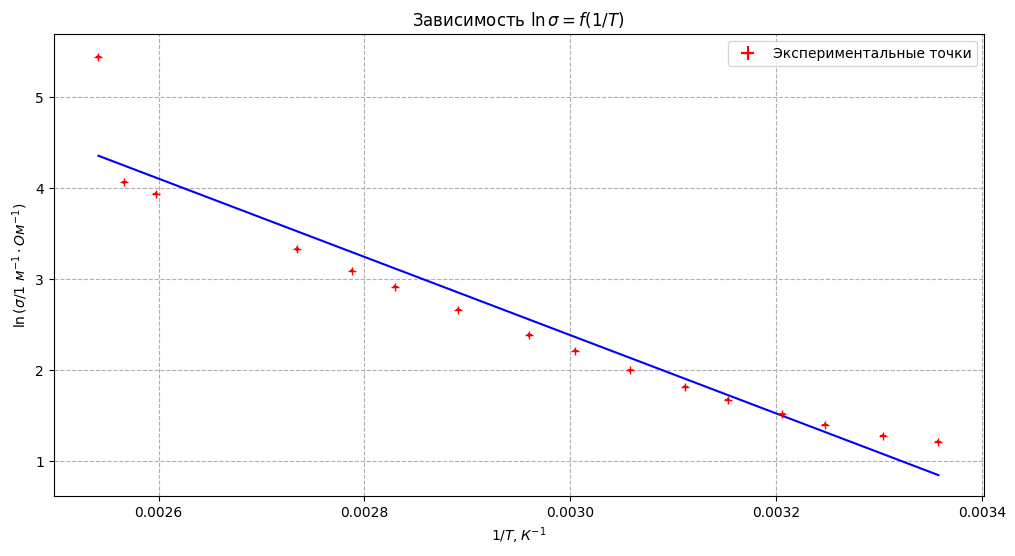

In [ ]:
plt.figure(figsize=(12, 6))
plt.grid(True, linestyle="--")
plt.title(r"Зависимость $\ln \sigma = f(1 / T)$")

plt.errorbar(x=data["1/T"], xerr=data["sigma_1/T"], y=data["ln_sigma"], yerr=data["sigma_ln_sigma"], fmt="+r", label="Экспериментальные точки")


# Линейная аппроксимация
popt, pcov = curve_fit(linear, xdata=data["1/T"], ydata=data["ln_sigma"], sigma=data["sigma_ln_sigma"], absolute_sigma=True)

x_model = np.linspace(min(data["1/T"]), max(data["1/T"]), 1000)
y_model = linear(x_model, *popt)

C, B = popt
sigma_C, sigma_B = np.sqrt(np.diag(pcov))

print(f"ln sigma = {B} {C} / T")
print(f"B = {B:.1f} +- {sigma_B:.1f}")

C_val = np.abs(C) / 100
sigma_C_val = sigma_C / 100

print(f"C = ({C_val:.1f} +- {sigma_C_val:.0f}) * 1e2 К")

plt.plot(x_model, y_model, "blue")




plt.xlabel(r"$1/T, К^{-1}$")
plt.ylabel(r"$\ln{ \left(\sigma / 1~м^{-1} \cdot Ом^{-1} \right)}$")

plt.legend()
plt.savefig("pictures/ln_sigma_T_graph.pdf")
plt.show()


Параметры прямой

$$ C = - \cfrac{\Delta}{2 k_\text{Б}} \implies \Delta = - 2 k_\text{Б} C $$

In [17]:
# Постоянная больцмана [1e-23 * Дж/К]
k_B = np.float128('1.380649')

In [18]:
Delta = - 2 * C * k_B
sigma_Delta = 2 * sigma_C * k_B

print(f"Delta = ({Delta:.0f} +- {sigma_Delta:.0f}) * 1e-23 Дж")

Delta_ev = Delta * 1e-4 / 1.6
sigma_Delta_ev = sigma_Delta * 1e-4 / 1.6

print(f"Delta_ev = ({Delta_ev:.2f} +- {sigma_Delta_ev:.2f})  эВ")

Delta = (11862 +- 925) * 1e-23 Дж
Delta_ev = (0.74 +- 0.06)  эВ
